# ML Feature Engineering — Exploration & Visualisation

Ce notebook couvre les deux premières étapes du pipeline ML :

1. **Chargement** — récupération des données OHLCV depuis la base SQLite
2. **Feature Engineering** — construction des features avec `FeatureBuilder`
3. **Exploration** — visualisation de chaque groupe de features
4. **Dataset supervisé** — création de X et y avec `DatasetBuilder`
5. **Splits temporels** — vérification de l'absence de data leakage
6. **Corrélation features → target** — identifier les features les plus prédictives

> **Rappel data leakage** : toutes les features ne doivent utiliser que des données disponibles à l'instant `t`.
> La target est construite à partir de `close(t + horizon)` et les `horizon` dernières lignes sont supprimées.

## 0. Setup

Imports et paramètres globaux. **Modifier ici** pour changer le symbole, le timeframe ou les paramètres du dataset.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.analytics.db_inspector import DBInspector
from src.ml.feature_engineering import FeatureBuilder, DatasetBuilder

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (14, 5)

# ── Paramètres à modifier selon l'analyse souhaitée ──────────────────────────
SYMBOL    = 'BTC/USDT'   # paire de trading présente en base
TIMEFRAME = '1d'          # '1h' | '4h' | '1d'
EXCHANGE  = 'binance'     # 'binance' | 'kraken' | 'coinbase'
HORIZON   = 1             # nombre de bougies dans le futur à prédire
MODE      = 'direction'   # 'direction' (classif 0/1) | 'return' (régression)
# ─────────────────────────────────────────────────────────────────────────────

print('Setup OK')

2026-03-29 16:57:24,714 - crypto_bot - INFO - ✅ Configuration chargée avec succès


Setup OK


## 1. Chargement des données OHLCV

Les données sont récupérées depuis la base SQLite via `DBInspector`.

**Points d'attention :**
- La colonne `timestamp` arrive en type `object` (string) depuis SQLite → conversion explicite en `datetime64` obligatoire avant tout tri ou calcul.
- On filtre sur `(symbol, timeframe, exchange)` car la table `ohlcv` contient plusieurs paires, timeframes et exchanges mélangés.
- On vérifie l'absence de doublons sur `timestamp` (peut arriver en cas de re-collecte partielle).
- On vérifie l'absence de trous dans la série (bougies manquantes).

In [2]:
inspector = DBInspector()

# Chargement brut — contient tous les symboles / timeframes / exchanges
raw_all = inspector.get_ohlcv_data_for_symbol(SYMBOL)

# Filtrage sur la combinaison souhaitée
raw = raw_all[
    (raw_all['timeframe'] == TIMEFRAME) &
    (raw_all['exchange']  == EXCHANGE)
].copy()

# ── Conversion du timestamp (SQLite retourne des strings, type object) ────────
# Un tri alphabétique sur string peut produire un ordre incorrect si le format
# varie (microsecondes, timezone...). La conversion en datetime64 est obligatoire.
raw['timestamp'] = pd.to_datetime(raw['timestamp'])

# Tri chronologique strict + reset de l'index (requis par FeatureBuilder)
raw = raw.sort_values('timestamp').reset_index(drop=True)

# ── Vérification 1 : doublons de timestamp ───────────────────────────────────
# Peut arriver si une collecte a été relancée sur une période déjà couverte.
n_dup = raw['timestamp'].duplicated().sum()
if n_dup > 0:
    print(f'⚠️  {n_dup} timestamp(s) dupliqué(s) — suppression (keep=last).')
    raw = raw.drop_duplicates(subset='timestamp', keep='last').reset_index(drop=True)
else:
    print('✅ Aucun doublon de timestamp.')

# ── Vérification 2 : trous dans la série (bougies manquantes) ────────────────
# Un trou peut biaiser les indicateurs glissants (SMA, RSI...) calculés sur
# un nombre fixe de bougies plutôt que sur une durée calendaire réelle.
freq_map = {'1h': '1h', '4h': '4h', '1d': '1D'}
expected_freq = freq_map.get(TIMEFRAME)
if expected_freq:
    expected_range = pd.date_range(raw['timestamp'].min(), raw['timestamp'].max(), freq=expected_freq)
    n_missing = len(expected_range) - len(raw)
    if n_missing > 0:
        print(f'⚠️  {n_missing} bougie(s) manquante(s) dans la série.')
        print('   Les indicateurs glissants seront calculés sur bougies consécutives, pas sur le temps réel.')
    else:
        print('✅ Série continue — aucun trou détecté.')

# ── Résumé ───────────────────────────────────────────────────────────────────
print(f'\nDonnées chargées : {len(raw)} bougies — {SYMBOL} {TIMEFRAME} [{EXCHANGE}]')
print(f"Période          : {raw['timestamp'].min().date()}  →  {raw['timestamp'].max().date()}")
print(f"Type timestamp   : {raw['timestamp'].dtype}  ← doit être datetime64")

raw[['timestamp', 'open', 'high', 'low', 'close', 'volume']].tail()

2026-03-29 16:57:25,032 - crypto_bot - INFO - Récupération des données OHLCV pour le symbole BTC/USDT...
2026-03-29 16:57:25,112 - crypto_bot - INFO - Données OHLCV récupérées avec succès. Forme: (4200, 16)


⚠️  896 timestamp(s) dupliqué(s) — suppression (keep=last).
✅ Série continue — aucun trou détecté.

Données chargées : 104 bougies — BTC/USDT 1d [binance]
Période          : 2025-11-02  →  2026-02-13
Type timestamp   : datetime64[ns]  ← doit être datetime64


,timestamp,open,high,low,close,volume
99,2026-02-09,70330.38,71453.53,68308.00,70481.77,28687.73347
100,2026-02-10,70138.00,70527.59,67800.00,68841.29,20373.77072
101,2026-02-11,68841.28,69292.88,65756.00,67082.52,28718.24602
102,2026-02-12,67082.52,68410.52,65118.00,66272.17,24271.74283
103,2026-02-13,66272.17,69482.97,65872.46,68813.39,18872.41628


## 2. Construction des features

`FeatureBuilder.build()` ajoute 30 features au DataFrame OHLCV en 6 groupes :

| Groupe | Features |
|---|---|
| Returns | `log_return_1`, `return_4/12/24` |
| Volatilité | `volatility_5/10/20` |
| Indicateurs techniques | RSI, MACD, Bollinger, SMA ratios, EMA ratios |
| Structure des bougies | spread H/L, corps, mèches |
| Volume | volume relatif, variation |
| Temporelles | heure, jour, mois, week-end |

Les premières lignes contiennent des `NaN` à cause du **warm-up** des indicateurs (ex. SMA(50) = 50 premières valeurs NaN).
Ces lignes seront supprimées automatiquement par `DatasetBuilder.build()`.

In [3]:
builder = FeatureBuilder()
df = builder.build(raw)

# Colonnes meta à exclure de l'analyse des features
_META = {
    'id', 'timestamp', 'symbol', 'timeframe', 'exchange', 'date',
    'created_at', 'updated_at',
    'open', 'high', 'low', 'close', 'volume',
    'price_range', 'price_change', 'price_change_pct'
}
feature_cols = [c for c in df.columns if c not in _META]

print(f'{len(feature_cols)} features construites :')
for col in feature_cols:
    print(f'  {col}')

2026-03-29 16:57:25,194 - crypto_bot - INFO - FeatureBuilder.build : 104 lignes, 45 colonnes totales (+29 features ajoutées).


29 features construites :
  log_return_1
  return_4
  return_12
  return_24
  volatility_5
  volatility_10
  volatility_20
  rsi_14
  macd
  macd_signal
  macd_hist
  bb_position
  bb_width
  sma_7_ratio
  sma_20_ratio
  sma_50_ratio
  ema_9_ratio
  ema_21_ratio
  hl_spread
  body_ratio
  upper_wick_ratio
  lower_wick_ratio
  volume_ma_ratio
  volume_change
  hour
  day_of_week
  day_of_month
  month
  is_weekend


In [4]:
# Statistiques descriptives — repérer les valeurs aberrantes :
# ex. RSI hors [0,100], ratio SMA très éloigné de 1, volatilité nulle...
df[feature_cols].describe().round(4)

,log_return_1,return_4,return_12,return_24,volatility_5,volatility_10,volatility_20,rsi_14,macd,macd_signal,...,body_ratio,upper_wick_ratio,lower_wick_ratio,volume_ma_ratio,volume_change,hour,day_of_week,day_of_month,month,is_weekend
count,103.0000,100.0000,92.0000,80.0000,99.0000,94.0000,84.0000,90.0000,71.0000,71.0000,...,104.0000,104.0000,104.0000,85.0000,103.0000,104.0,104.0000,104.0000,104.0000,104.0000
mean,-0.0046,-0.0163,-0.0459,-0.0570,0.0234,0.0241,0.0226,41.0430,-1537.9678,15.1456,...,0.4235,0.2687,0.3078,1.0451,0.1968,0.0,2.9808,14.8750,7.1923,0.2788
std,0.0289,0.0493,0.0850,0.1035,0.0180,0.0148,0.0104,11.5902,2037.5019,893.8701,...,0.2443,0.1987,0.1992,0.6521,0.7392,0.0,2.0096,8.8643,5.0973,0.4506
min,-0.1510,-0.1827,-0.2949,-0.3109,0.0039,0.0058,0.0108,15.8144,-5872.4060,-2251.9921,...,0.0142,0.0000,0.0000,0.2522,-0.8036,0.0,0.0000,1.0000,1.0000,0.0000
25%,-0.0180,-0.0440,-0.1070,-0.1231,0.0150,0.0163,0.0149,33.4792,-2266.9839,-620.4189,...,0.2255,0.1217,0.1822,0.6028,-0.2267,0.0,1.0000,7.0000,1.0000,0.0000
50%,-0.0015,-0.0107,-0.0291,-0.0270,0.0193,0.0207,0.0225,42.1188,-1414.9997,281.5808,...,0.4291,0.2324,0.2552,0.8991,0.0157,0.0,3.0000,14.0000,11.0000,0.0000
75%,0.0104,0.0191,0.0155,0.0157,0.0236,0.0264,0.0245,46.6284,100.6750,574.1653,...,0.6247,0.3773,0.4145,1.3462,0.4158,0.0,5.0000,22.2500,12.0000,1.0000
max,0.1150,0.1204,0.0975,0.0935,0.0972,0.0681,0.0505,69.7516,1516.7547,1660.8977,...,0.9327,0.7547,0.8686,4.1418,3.4745,0.0,6.0000,31.0000,12.0000,1.0000


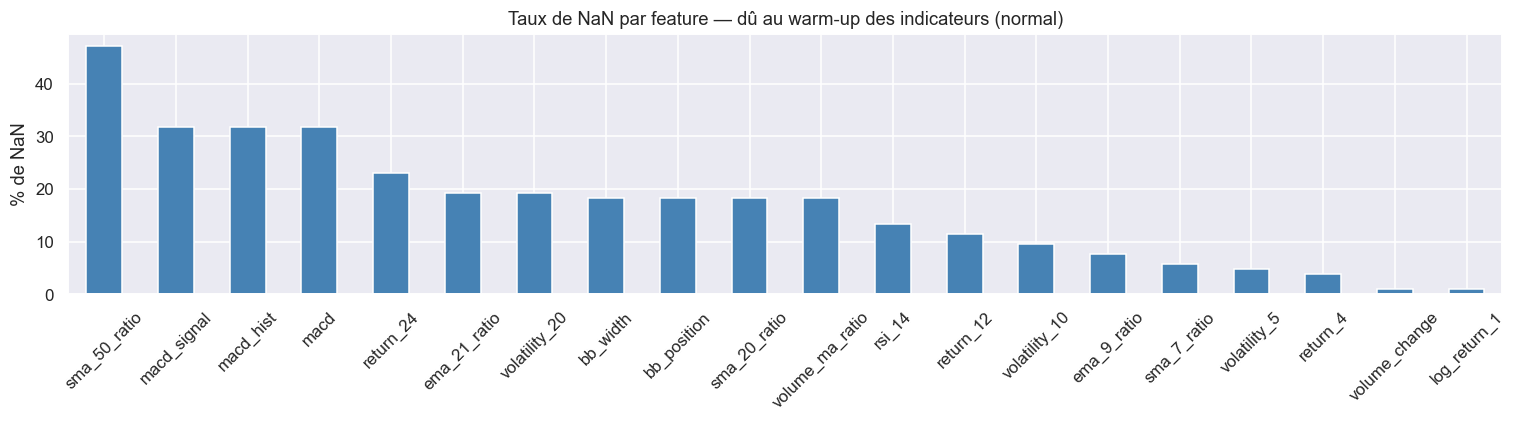

Lignes sans NaN : 55 / 104  (52.9% utilisables pour le ML)


In [5]:
# Taux de NaN par feature — normal pour les indicateurs avec grande fenêtre.
# La feature avec le plus de NaN (sma_50 → 50 lignes) détermine combien de
# lignes seront perdues après dropna() dans DatasetBuilder.
nan_pct = df[feature_cols].isna().mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(14, 4))
nan_pct[nan_pct > 0].plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Taux de NaN par feature — dû au warm-up des indicateurs (normal)')
ax.set_ylabel('% de NaN')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

n_clean = df[feature_cols].dropna().shape[0]
print(f'Lignes sans NaN : {n_clean} / {len(df)}  ({n_clean/len(df)*100:.1f}% utilisables pour le ML)')

## 3. Visualisation des features par groupe

### 3.1 Returns (variation relative du prix entre deux instants — exprimé en % ou en décimal) & Momentum

Les returns logarithmiques et les returns simples sur différents horizons mesurent le **momentum** du prix.
On s'attend à des distributions proches d'une gaussienne centrée sur 0, souvent avec des queues épaisses (fat tails).
Un biais positif moyen indique une tendance haussière sur la période observée.

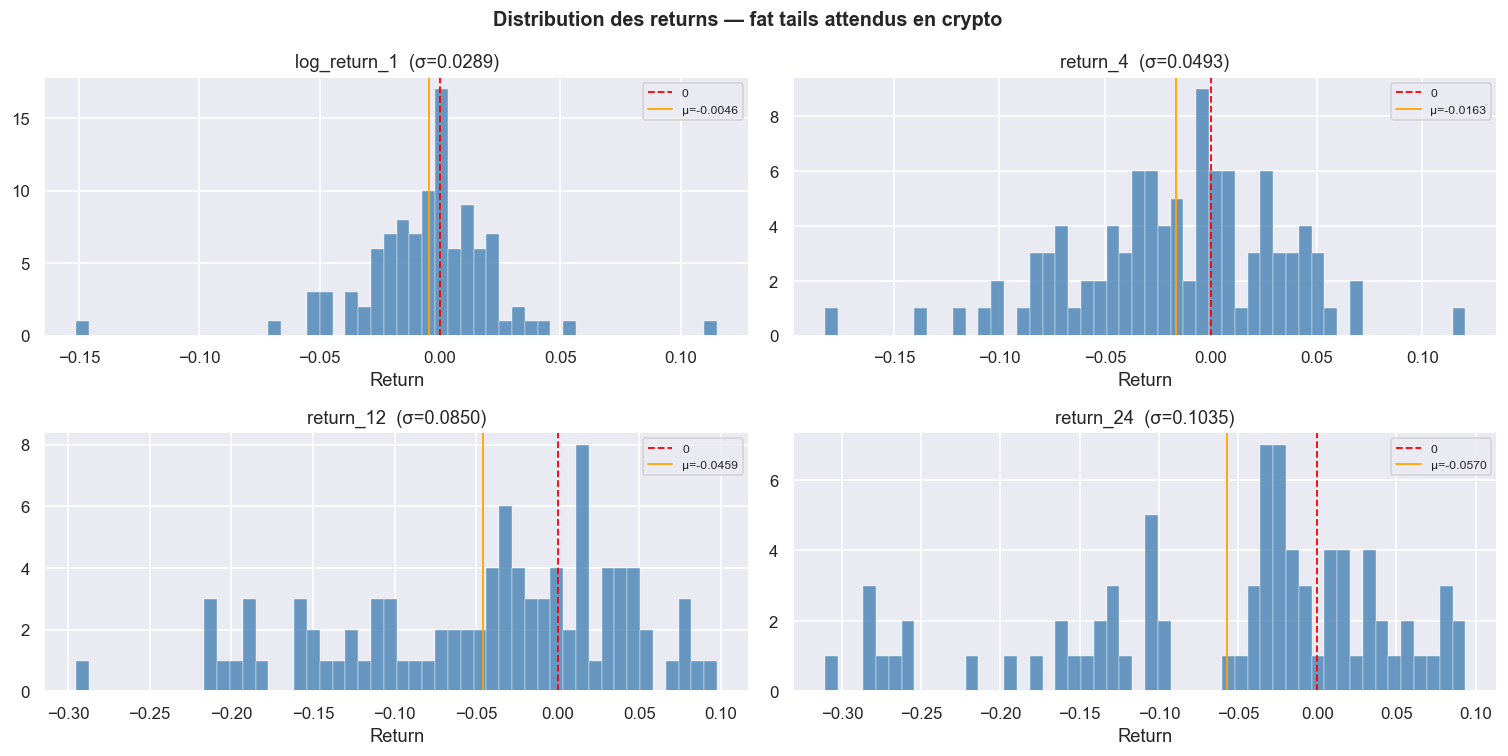

In [6]:
return_cols = ['log_return_1', 'return_4', 'return_12', 'return_24']

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(return_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=50, color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.3)
    axes[i].axvline(0, color='red', linestyle='--', linewidth=1.2, label='0')
    axes[i].axvline(data.mean(), color='orange', linestyle='-', linewidth=1.2,
                    label=f'μ={data.mean():.4f}')
    axes[i].set_title(f'{col}  (σ={data.std():.4f})')
    axes[i].set_xlabel('Return')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution des returns — fat tails attendus en crypto', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

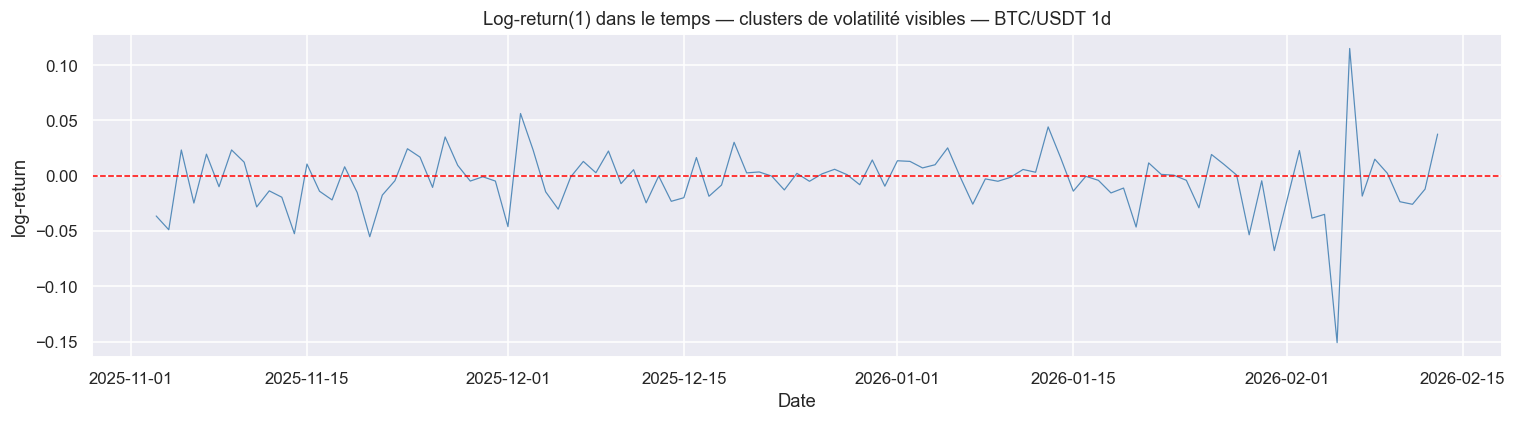

In [7]:
# Série temporelle du log-return.
# Les clusters de forte volatilité (hétéroscédasticité) sont typiques des marchés crypto.
# Le modèle ML devra gérer ces changements de régime.
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['timestamp'], df['log_return_1'], color='steelblue', linewidth=0.8, alpha=0.9)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_title(f'Log-return(1) dans le temps — clusters de volatilité visibles — {SYMBOL} {TIMEFRAME}')
ax.set_xlabel('Date')
ax.set_ylabel('log-return')
plt.tight_layout()
plt.show()

### 3.2 Volatilité

La volatilité réalisée est calculée comme l'écart-type glissant des log-returns.
- **volatilité élevée** → marché turbulent, prédictions moins fiables
- **volatilité faible** → marché calme, signaux plus fiables

`volatility_5` (rouge) est la plus réactive aux chocs. `volatility_20` (vert) représente le régime de fond.

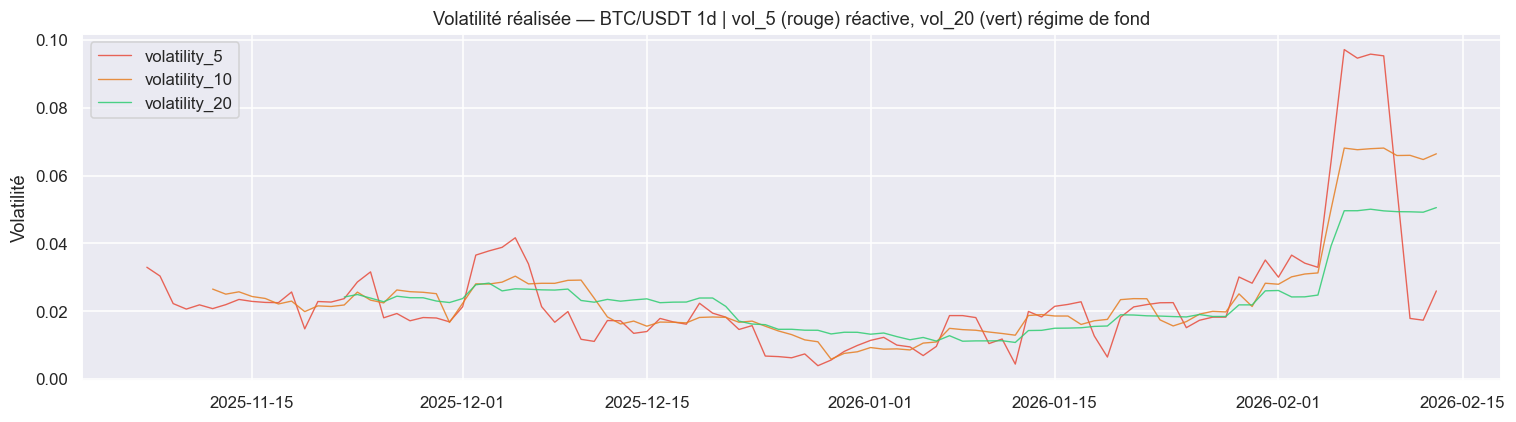

In [8]:
vol_cols = ['volatility_5', 'volatility_10', 'volatility_20']
colors   = ['#e74c3c', '#e67e22', '#2ecc71']

fig, ax = plt.subplots(figsize=(14, 4))
for col, color in zip(vol_cols, colors):
    ax.plot(df['timestamp'], df[col], label=col, color=color, linewidth=0.9, alpha=0.85)

ax.set_title(f'Volatilité réalisée — {SYMBOL} {TIMEFRAME} | vol_5 (rouge) réactive, vol_20 (vert) régime de fond')
ax.set_ylabel('Volatilité')
ax.legend()
plt.tight_layout()
plt.show()

### 3.3 Indicateurs techniques

Les indicateurs sont exprimés sous forme de **ratios normalisés** (prix / SMA, position dans les BB)
plutôt qu'en valeurs absolues, pour être comparables entre différentes cryptos et périodes.

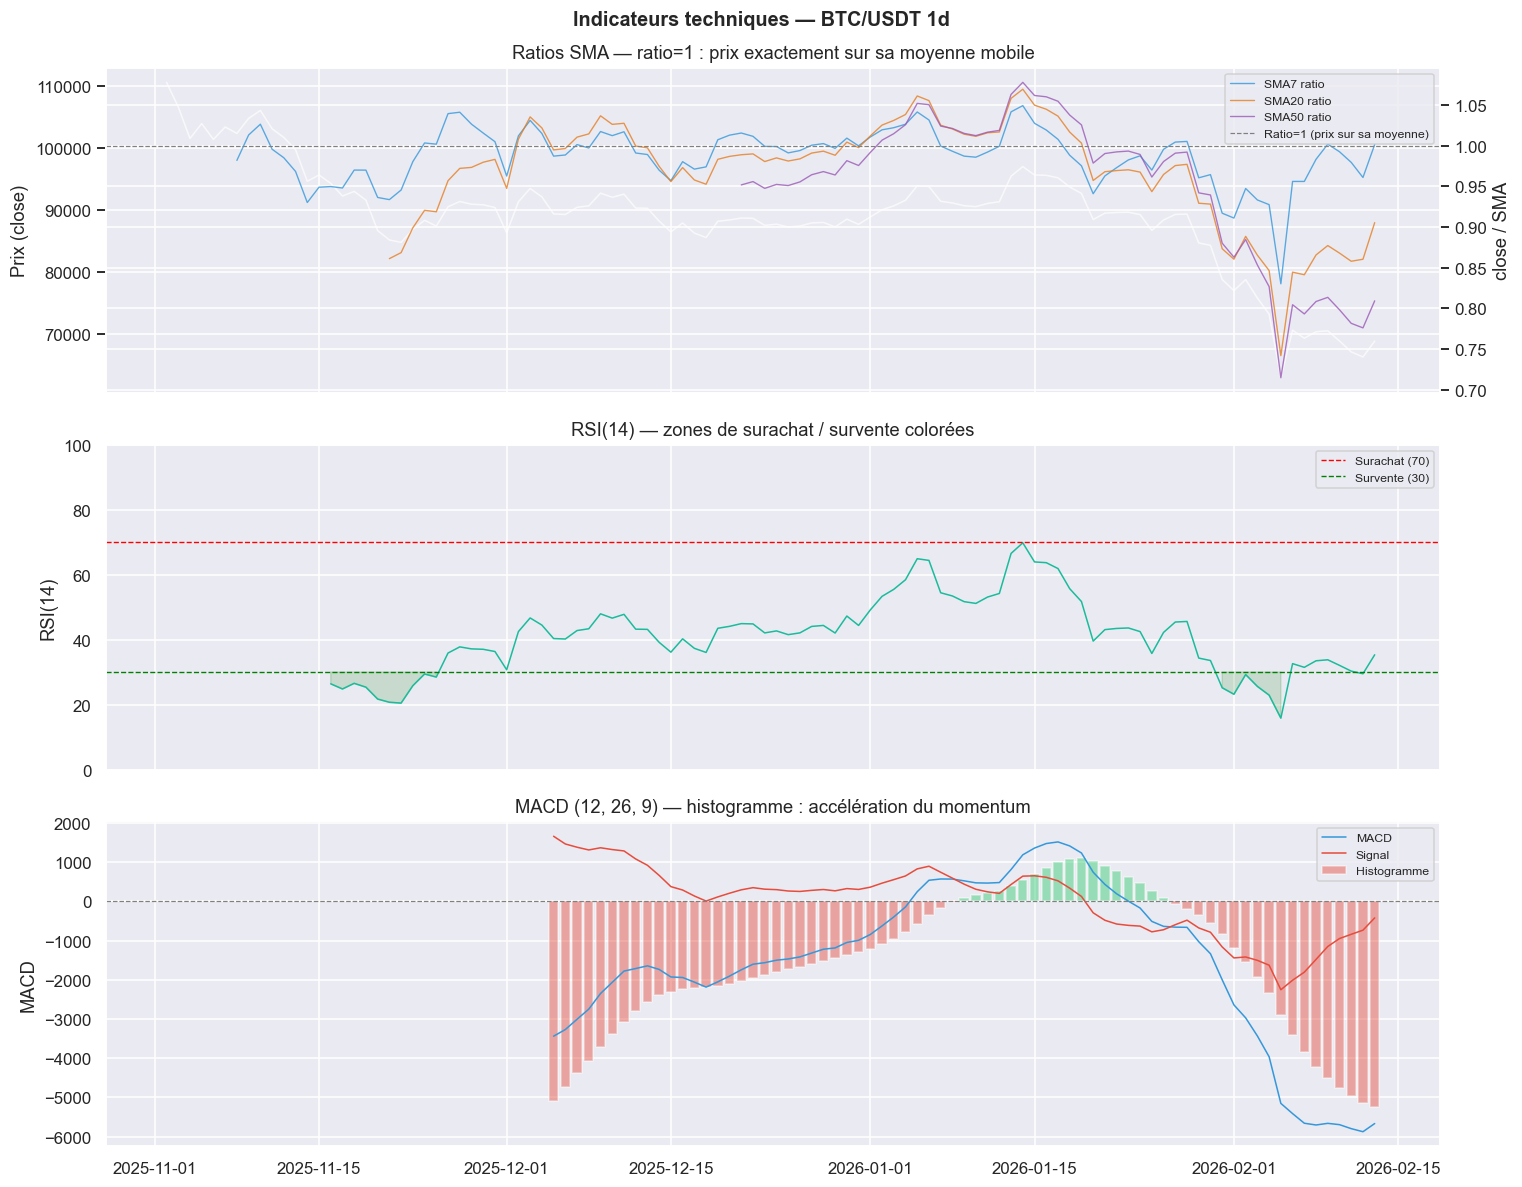

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

# ── Panneau 1 : Ratios SMA ────────────────────────────────────────────────────
# ratio > 1 : prix au-dessus de sa moyenne → tendance haussière
# Croisement SMA7/SMA50 : golden cross (signal achat) / death cross (signal vente)
ax0b = axes[0].twinx()
axes[0].plot(df['timestamp'], df['close'], color='white', linewidth=1, label='Close', alpha=0.7)
ax0b.plot(df['timestamp'], df['sma_7_ratio'],  color='#3498db', linewidth=0.9, alpha=0.8, label='SMA7 ratio')
ax0b.plot(df['timestamp'], df['sma_20_ratio'], color='#e67e22', linewidth=0.9, alpha=0.8, label='SMA20 ratio')
ax0b.plot(df['timestamp'], df['sma_50_ratio'], color='#9b59b6', linewidth=0.9, alpha=0.8, label='SMA50 ratio')
ax0b.axhline(1, color='gray', linestyle='--', linewidth=0.8, label='Ratio=1 (prix sur sa moyenne)')
axes[0].set_ylabel('Prix (close)')
ax0b.set_ylabel('close / SMA')
ax0b.legend(loc='upper right', fontsize=8)
axes[0].set_title('Ratios SMA — ratio=1 : prix exactement sur sa moyenne mobile')

# ── Panneau 2 : RSI ───────────────────────────────────────────────────────────
# RSI > 70 : surachat (risque retournement baissier) | RSI < 30 : survente (risque rebond)
axes[1].plot(df['timestamp'], df['rsi_14'], color='#1abc9c', linewidth=1)
axes[1].axhline(70, color='red',   linestyle='--', linewidth=0.9, label='Surachat (70)')
axes[1].axhline(30, color='green', linestyle='--', linewidth=0.9, label='Survente (30)')
axes[1].fill_between(df['timestamp'], 70, df['rsi_14'].clip(upper=100),
                      where=df['rsi_14'] >= 70, alpha=0.15, color='red')
axes[1].fill_between(df['timestamp'], df['rsi_14'].clip(lower=0), 30,
                      where=df['rsi_14'] <= 30, alpha=0.15, color='green')
axes[1].set_ylim(0, 100)
axes[1].set_ylabel('RSI(14)')
axes[1].legend(fontsize=8)
axes[1].set_title('RSI(14) — zones de surachat / survente colorées')

# ── Panneau 3 : MACD ─────────────────────────────────────────────────────────
# Histogramme vert : momentum haussier qui accélère | rouge : momentum baissier
# Croisement MACD/Signal : signal d'achat ou de vente selon la direction
axes[2].plot(df['timestamp'], df['macd'],        color='#3498db', linewidth=1, label='MACD')
axes[2].plot(df['timestamp'], df['macd_signal'], color='#e74c3c', linewidth=1, label='Signal')
hist_colors = df['macd_hist'].apply(lambda x: '#2ecc71' if x >= 0 else '#e74c3c')
axes[2].bar(df['timestamp'], df['macd_hist'], color=hist_colors, alpha=0.45, label='Histogramme')
axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_ylabel('MACD')
axes[2].legend(fontsize=8)
axes[2].set_title('MACD (12, 26, 9) — histogramme : accélération du momentum')

plt.suptitle(f'Indicateurs techniques — {SYMBOL} {TIMEFRAME}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

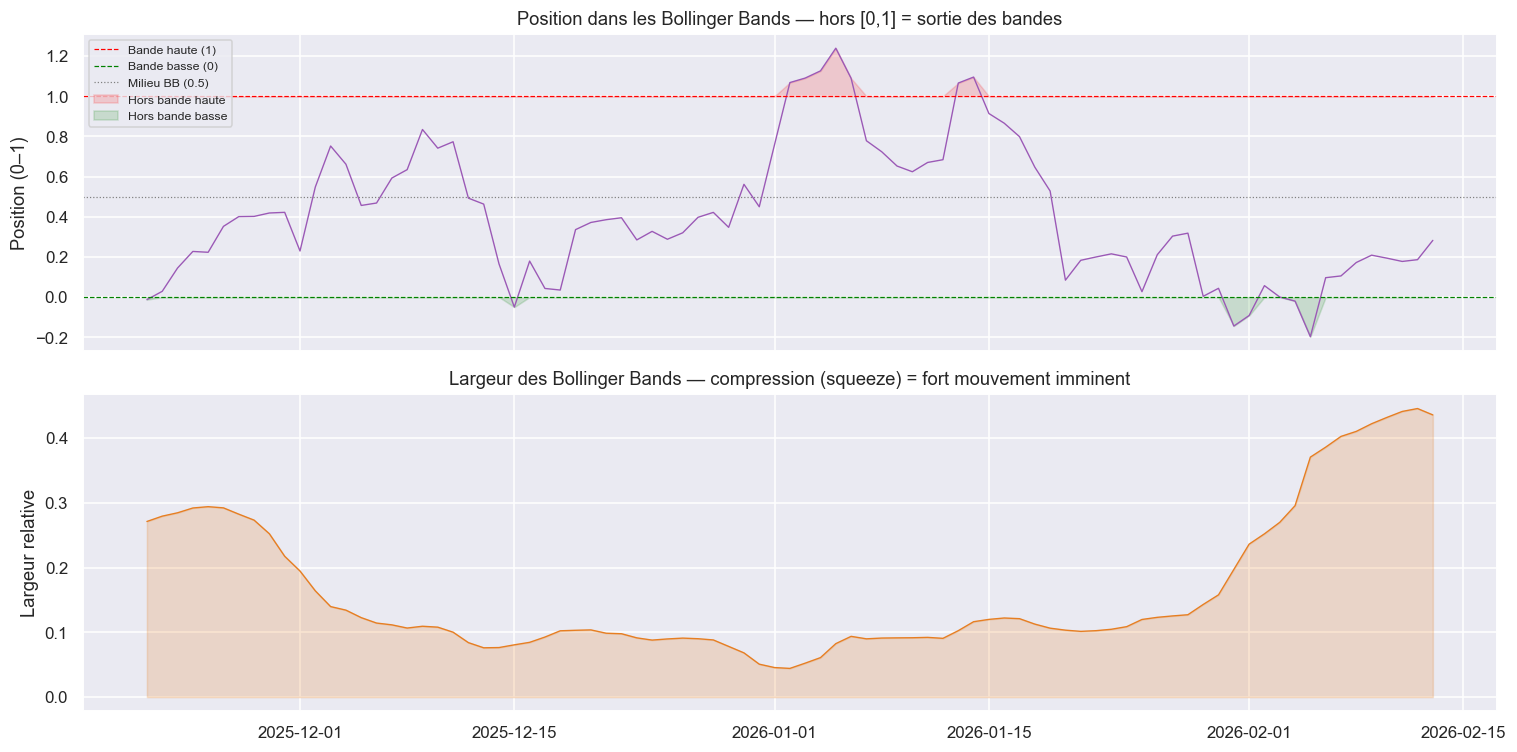

In [10]:
# Bollinger Bands — deux features dérivées :
# bb_position : 0 = prix sur bande basse, 1 = prix sur bande haute.
#   Valeurs > 1 ou < 0 : sortie des bandes (événement rare = fort signal de continuation ou retournement).
# bb_width : largeur relative = proxy de volatilité.
#   Compression (squeeze) → fort mouvement directionnel imminent.
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(df['timestamp'], df['bb_position'], color='#9b59b6', linewidth=0.9)
axes[0].axhline(1,   color='red',   linestyle='--', linewidth=0.8, label='Bande haute (1)')
axes[0].axhline(0,   color='green', linestyle='--', linewidth=0.8, label='Bande basse (0)')
axes[0].axhline(0.5, color='gray',  linestyle=':',  linewidth=0.8, label='Milieu BB (0.5)')
axes[0].fill_between(df['timestamp'], 1, df['bb_position'].clip(lower=1),
                      alpha=0.15, color='red', label='Hors bande haute')
axes[0].fill_between(df['timestamp'], df['bb_position'].clip(upper=0), 0,
                      alpha=0.15, color='green', label='Hors bande basse')
axes[0].set_ylabel('Position (0–1)')
axes[0].set_title('Position dans les Bollinger Bands — hors [0,1] = sortie des bandes')
axes[0].legend(fontsize=8, loc='upper left')

axes[1].plot(df['timestamp'], df['bb_width'], color='#e67e22', linewidth=0.9)
axes[1].fill_between(df['timestamp'], df['bb_width'], alpha=0.2, color='#e67e22')
axes[1].set_ylabel('Largeur relative')
axes[1].set_title('Largeur des Bollinger Bands — compression (squeeze) = fort mouvement imminent')

plt.tight_layout()
plt.show()

### 3.4 Structure des bougies

Ces features capturent la **psychologie du marché** à l'intérieur de chaque bougie :
- **body_ratio → 1** : bougie marubozu (conviction forte) | **→ 0** : doji (indécision, retournement potentiel)
- **upper_wick élevée** : rejet de la hausse par les vendeurs
- **lower_wick élevée** : rejet de la baisse par les acheteurs

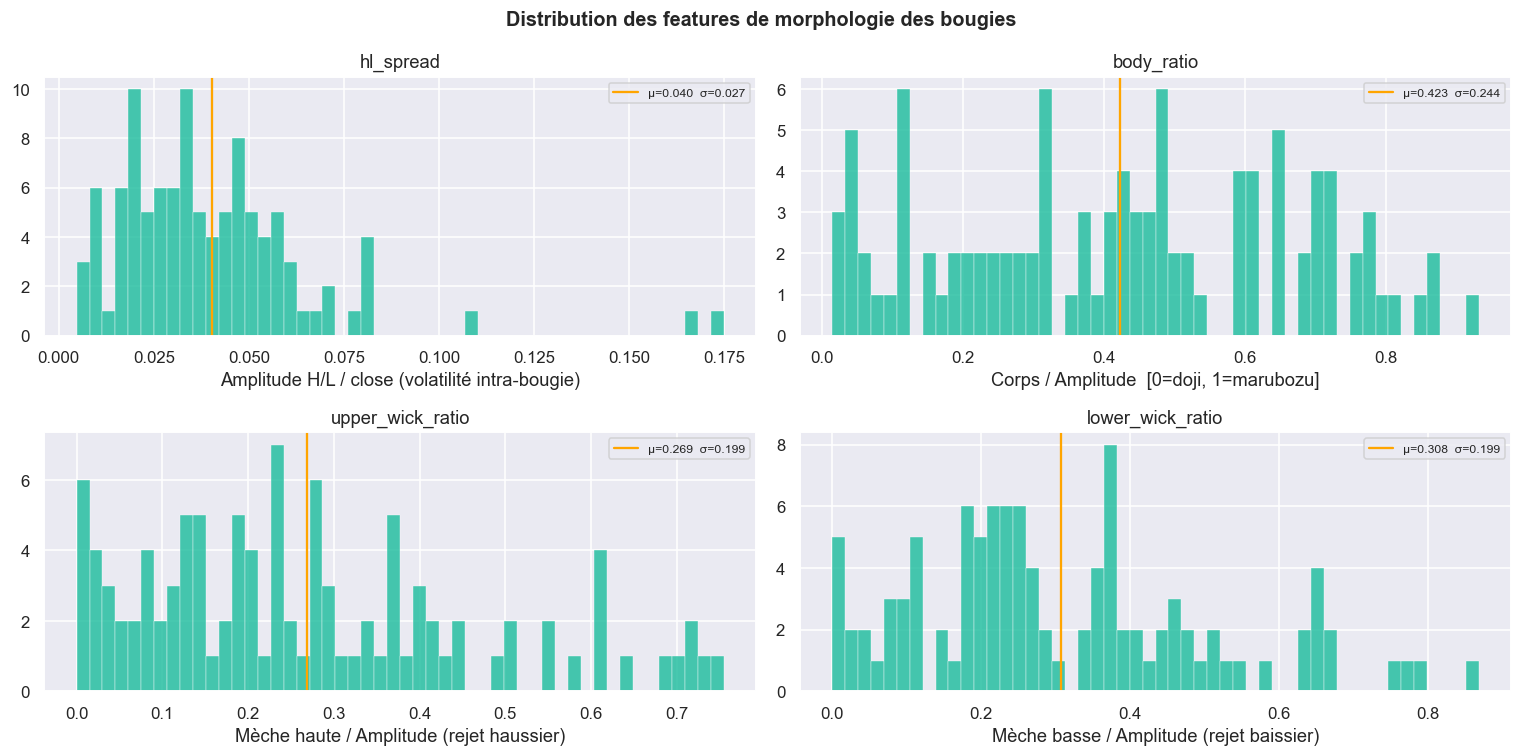

In [11]:
candle_cols  = ['hl_spread', 'body_ratio', 'upper_wick_ratio', 'lower_wick_ratio']
candle_descs = [
    'Amplitude H/L / close (volatilité intra-bougie)',
    'Corps / Amplitude  [0=doji, 1=marubozu]',
    'Mèche haute / Amplitude (rejet haussier)',
    'Mèche basse / Amplitude (rejet baissier)'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes = axes.flatten()

for i, (col, desc) in enumerate(zip(candle_cols, candle_descs)):
    data = df[col].dropna()
    axes[i].hist(data, bins=50, color='#1abc9c', alpha=0.8, edgecolor='white', linewidth=0.3)
    axes[i].axvline(data.mean(), color='orange', linewidth=1.5,
                    label=f'μ={data.mean():.3f}  σ={data.std():.3f}')
    axes[i].set_title(col)
    axes[i].set_xlabel(desc)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution des features de morphologie des bougies', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5 Volume

Le volume brut n'est pas comparable entre périodes ou cryptos. On utilise des **volumes relatifs** :
- `volume_ma_ratio > 2` → volume anormalement élevé → signal de confirmation (breakout) ou de capitulation
- `volume_change` → accélération / décélération soudaine du volume

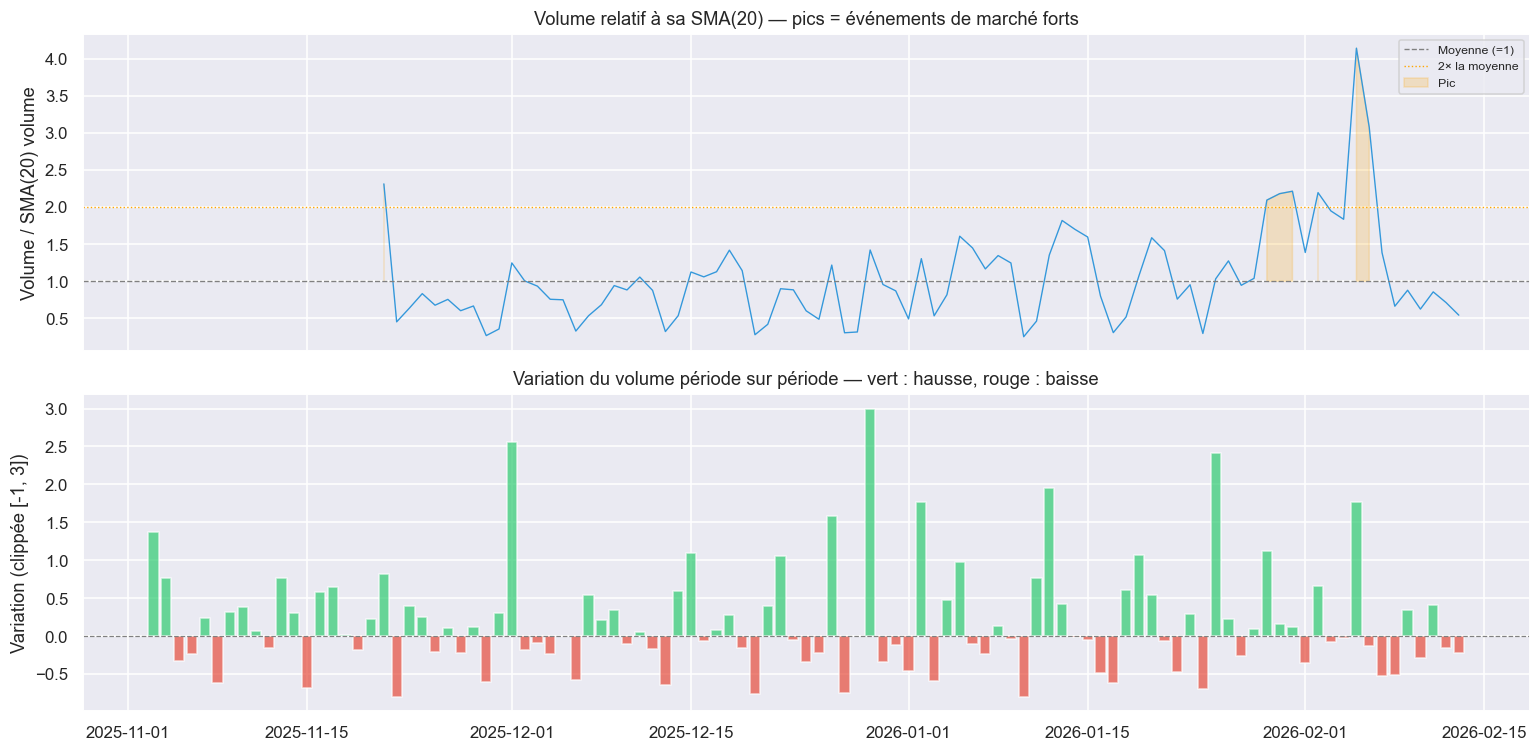

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Volume / SMA(20) — zone orange : pics de volume souvent liés à des événements forts
axes[0].plot(df['timestamp'], df['volume_ma_ratio'], color='#3498db', linewidth=0.9)
axes[0].axhline(1, color='gray',   linestyle='--', linewidth=0.9, label='Moyenne (=1)')
axes[0].axhline(2, color='orange', linestyle=':',  linewidth=0.9, label='2× la moyenne')
axes[0].fill_between(df['timestamp'], df['volume_ma_ratio'], 1,
                      where=df['volume_ma_ratio'] >= 2, alpha=0.2, color='orange', label='Pic')
axes[0].set_ylabel('Volume / SMA(20) volume')
axes[0].set_title('Volume relatif à sa SMA(20) — pics = événements de marché forts')
axes[0].legend(fontsize=8)

# Variation période sur période — barres vertes : accélération (souvent en début de tendance)
vc = df['volume_change'].clip(-1, 3)
colors_vc = vc.apply(lambda x: '#2ecc71' if x >= 0 else '#e74c3c')
axes[1].bar(df['timestamp'], vc, color=colors_vc, alpha=0.7)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_ylabel('Variation (clippée [-1, 3])')
axes[1].set_title('Variation du volume période sur période — vert : hausse, rouge : baisse')

plt.tight_layout()
plt.show()

### 3.6 Features temporelles

Le marché crypto fonctionne 24/7 mais présente des **patterns calendaires** :
- **Heure** : volumes et volatilité plus élevés à l'ouverture des marchés européens (8h–10h UTC) et américains (14h–16h UTC)
- **Jour de semaine** : week-ends généralement moins liquides
- **Mois** : certains mois sont historiquement plus haussiers ("Uptober", effet janvier...)

> Pertinentes surtout sur 1h / 4h. Sur 1d, seuls le jour de semaine et le mois ont du sens.

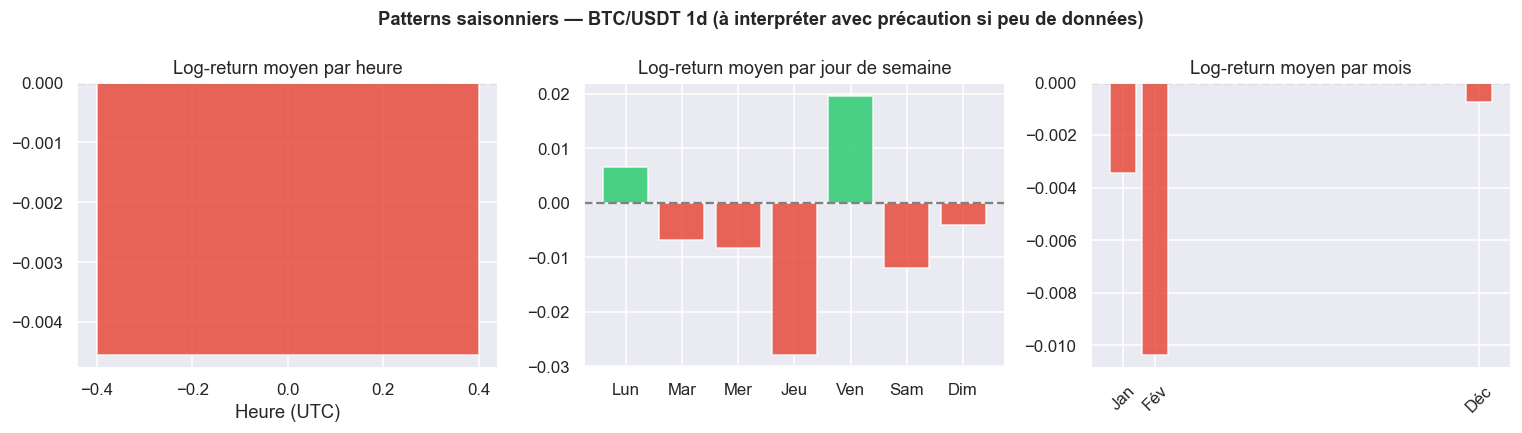

In [13]:
df_clean = df.dropna(subset=feature_cols).copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ret_by_hour = df_clean.groupby('hour')['log_return_1'].mean()
axes[0].bar(ret_by_hour.index, ret_by_hour.values,
            color=['#2ecc71' if v >= 0 else '#e74c3c' for v in ret_by_hour.values], alpha=0.85)
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].set_title('Log-return moyen par heure')
axes[0].set_xlabel('Heure (UTC)')

day_labels = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']
ret_by_day = df_clean.groupby('day_of_week')['log_return_1'].mean()
axes[1].bar(ret_by_day.index, ret_by_day.values,
            color=['#2ecc71' if v >= 0 else '#e74c3c' for v in ret_by_day.values], alpha=0.85)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_labels)
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_title('Log-return moyen par jour de semaine')

month_labels = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
ret_by_month = df_clean.groupby('month')['log_return_1'].mean()
axes[2].bar(ret_by_month.index, ret_by_month.values,
            color=['#2ecc71' if v >= 0 else '#e74c3c' for v in ret_by_month.values], alpha=0.85)
axes[2].set_xticks(ret_by_month.index)
axes[2].set_xticklabels([month_labels[m-1] for m in ret_by_month.index], rotation=45)
axes[2].axhline(0, color='gray', linestyle='--')
axes[2].set_title('Log-return moyen par mois')

plt.suptitle(f'Patterns saisonniers — {SYMBOL} {TIMEFRAME} (à interpréter avec précaution si peu de données)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Matrice de corrélation des features

Objectif : détecter la **redondance** entre features (|r| > 0.85 → information quasi-identique).
LightGBM / XGBoost gèrent la redondance nativement. La régression logistique est plus sensible.

> Les features temporelles (catégorielles ordinales) sont exclues — Pearson n'est pas adapté.

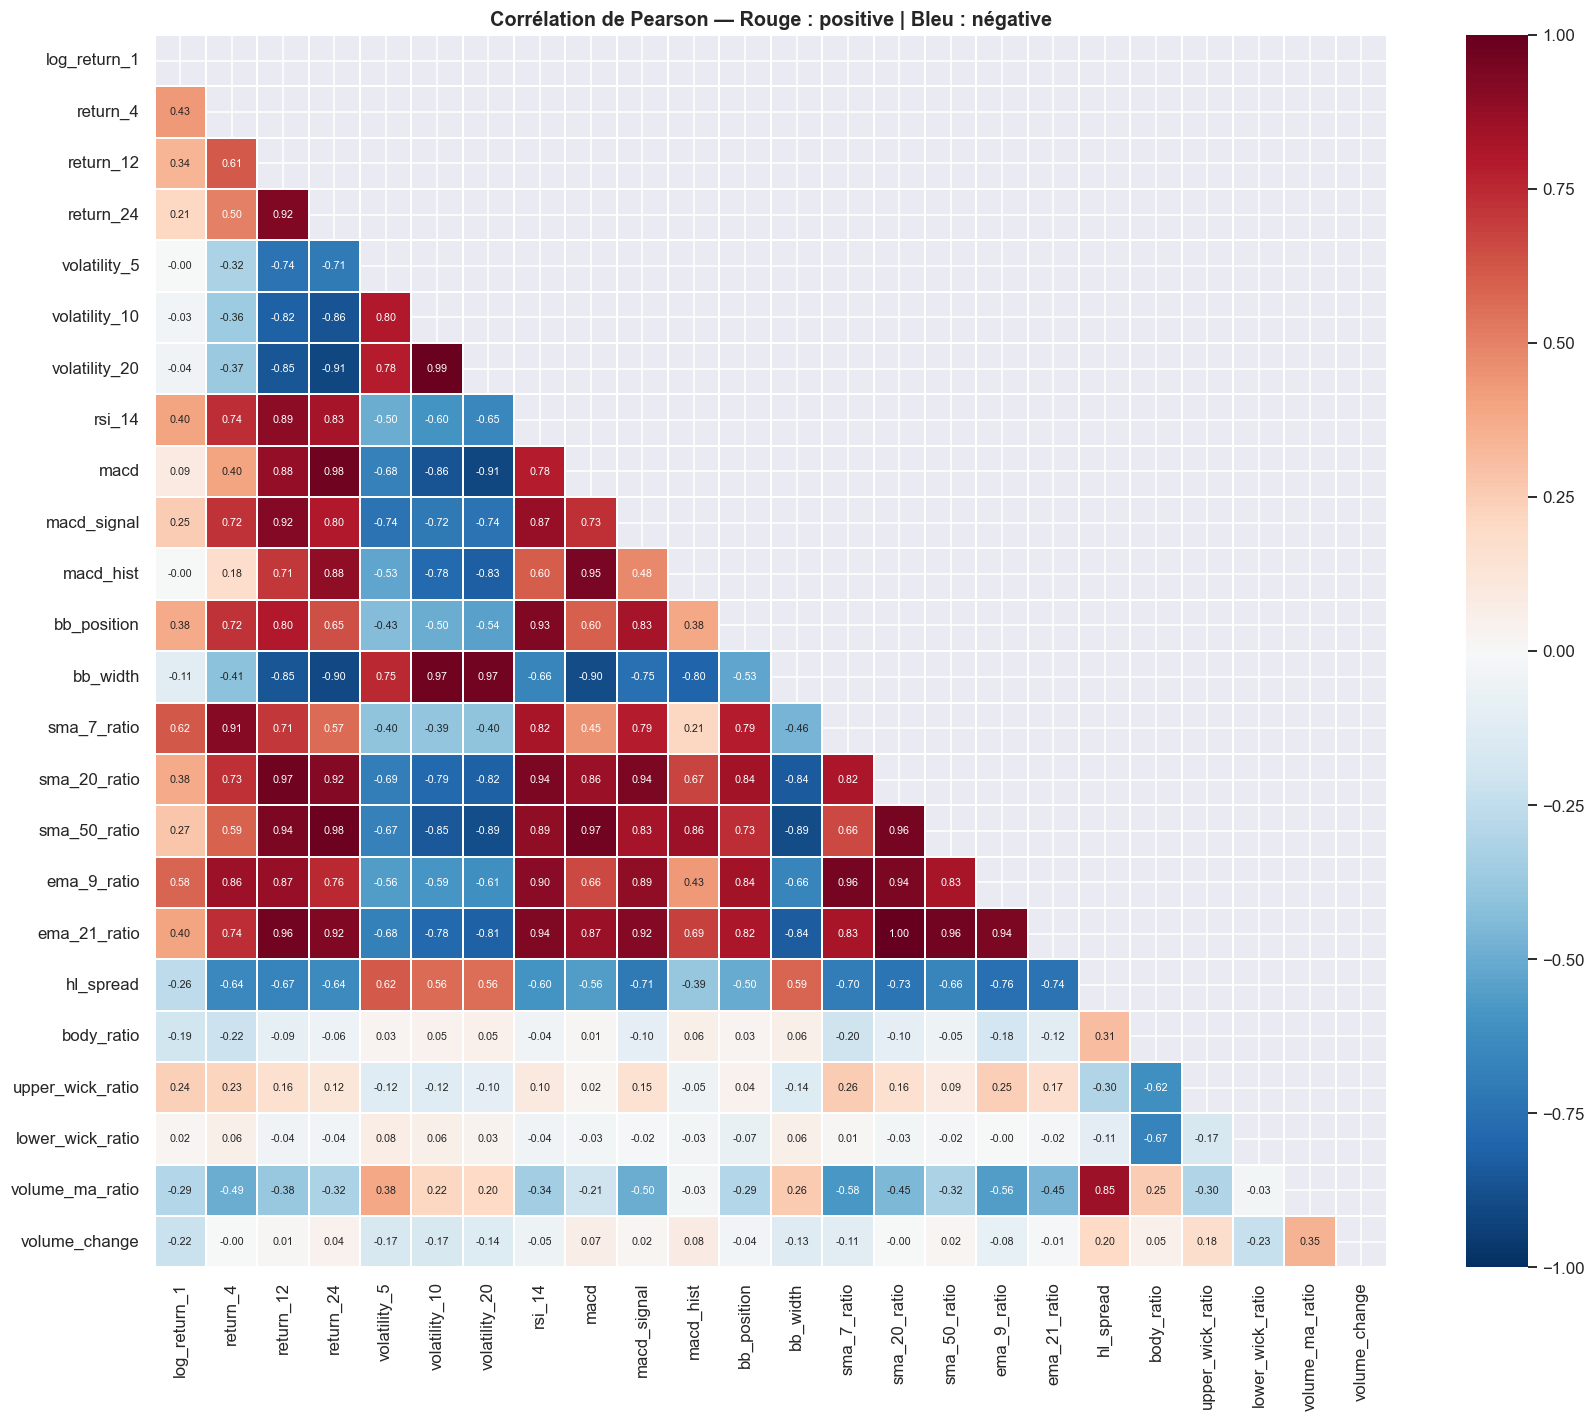

In [14]:
temporal_cols = ['hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend']
num_features  = [c for c in feature_cols if c not in temporal_cols]
corr = df[num_features].dropna().corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))  # masquer le triangle supérieur (redondant)
sns.heatmap(corr, mask=mask, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7}, linewidths=0.3, square=True)
ax.set_title('Corrélation de Pearson — Rouge : positive | Bleu : négative', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# Paires fortement corrélées (|r| > 0.85) — candidats à la suppression ou fusion en Phase 2
corr_pairs = (corr.abs()
    .where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
    .stack().reset_index())
corr_pairs.columns = ['feature_1', 'feature_2', 'correlation']
high_corr = corr_pairs[corr_pairs['correlation'] > 0.85].sort_values('correlation', ascending=False)

if len(high_corr) > 0:
    print(f'⚠️  {len(high_corr)} paire(s) fortement corrélée(s) (|r| > 0.85) :')
    print(high_corr.to_string(index=False))
else:
    print('✅ Aucune paire fortement corrélée — bonne diversité.')

⚠️  49 paire(s) fortement corrélée(s) (|r| > 0.85) :
      feature_1     feature_2  correlation
   ema_21_ratio  sma_20_ratio     0.997688
  volatility_20 volatility_10     0.986610
   sma_50_ratio     return_24     0.977812
           macd     return_24     0.975777
       bb_width volatility_10     0.974228
   sma_20_ratio     return_12     0.968972
       bb_width volatility_20     0.968271
   sma_50_ratio          macd     0.965187
   ema_21_ratio  sma_50_ratio     0.961881
   ema_21_ratio     return_12     0.961446
    ema_9_ratio   sma_7_ratio     0.960045
   sma_50_ratio  sma_20_ratio     0.956511
      macd_hist          macd     0.947527
   ema_21_ratio   ema_9_ratio     0.943419
   sma_50_ratio     return_12     0.942712
   sma_20_ratio        rsi_14     0.940915
   sma_20_ratio   macd_signal     0.940102
    ema_9_ratio  sma_20_ratio     0.938037
   ema_21_ratio        rsi_14     0.935324
    bb_position        rsi_14     0.928465
      return_24     return_12     0.924940
 

## 5. Construction du dataset supervisé

`DatasetBuilder.build()` réalise 3 opérations :
1. **Crée la target** : `close(t + horizon) > close(t)` → 1 (hausse) / 0 (baisse) en mode `direction`
2. **Supprime les colonnes meta** (timestamp, prix bruts, symbole...)
3. **Supprime les NaN** : premières lignes (warm-up) + dernières lignes (target future absente)

> **Anti-data leakage** : les `horizon` dernières lignes sont supprimées car `close(t + horizon)` n'est pas encore connu.

In [16]:
ds_builder = DatasetBuilder(horizon=HORIZON, mode=MODE)
X, y = ds_builder.build(df)

print(f'Dataset final : {X.shape[0]} lignes × {X.shape[1]} features')
print(f'Target        : mode={MODE}, horizon={HORIZON} bougie(s)')
print(f'NaN dans X    : {X.isna().sum().sum()}  (doit être 0)')
print(f'NaN dans y    : {y.isna().sum()}  (doit être 0)')

if MODE == 'direction':
    n0, n1 = (y == 0).sum(), (y == 1).sum()
    print(f'\nÉquilibre : 0 (baisse) = {n0} ({n0/len(y)*100:.1f}%)  |  1 (hausse) = {n1} ({n1/len(y)*100:.1f}%)')
    if abs(n0 - n1) / len(y) > 0.1:
        print('⚠️  Déséquilibre > 10% — envisager class_weight="balanced".')
    else:
        print('✅ Classes équilibrées.')
else:
    print(f'Return : μ={y.mean():.4f}  σ={y.std():.4f}  min={y.min():.4f}  max={y.max():.4f}')

2026-03-29 16:57:27,646 - crypto_bot - INFO - DatasetBuilder.build : 49 lignes supprimées (NaN / horizon). Dataset : 55 lignes × 29 features. Horizon=1, mode='direction'.


Dataset final : 55 lignes × 29 features
Target        : mode=direction, horizon=1 bougie(s)
NaN dans X    : 0  (doit être 0)
NaN dans y    : 0  (doit être 0)

Équilibre : 0 (baisse) = 30 (54.5%)  |  1 (hausse) = 25 (45.5%)
✅ Classes équilibrées.


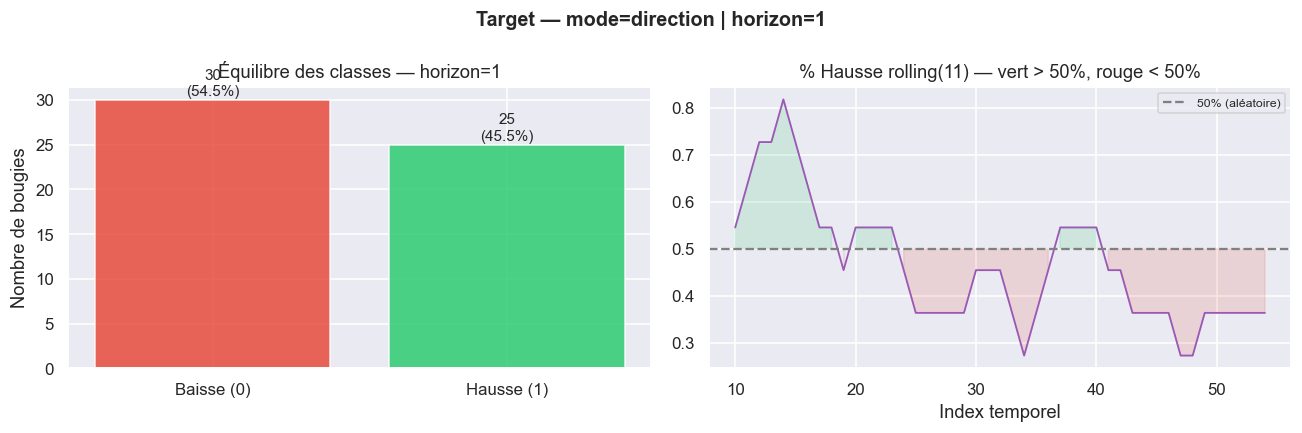

In [17]:
# Panneau gauche : distribution (équilibre classes ou distribution returns)
# Panneau droit  : % de hausses dans le temps — déséquilibre lié à une tendance ou aux régimes ?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if MODE == 'direction':
    counts = y.value_counts().sort_index()
    bars = axes[0].bar(['Baisse (0)', 'Hausse (1)'], counts.values,
                       color=['#e74c3c', '#2ecc71'], alpha=0.85)
    for bar, val in zip(bars, counts.values):
        axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                     f'{val}\n({val/len(y)*100:.1f}%)', ha='center', fontsize=10)
    axes[0].set_title(f'Équilibre des classes — horizon={HORIZON}')
    axes[0].set_ylabel('Nombre de bougies')

    window_roll = min(30, len(y) // 5)
    rolling_pct = y.rolling(window_roll).mean()
    axes[1].plot(rolling_pct.values, color='#9b59b6', linewidth=1.2)
    axes[1].axhline(0.5, color='gray', linestyle='--', label='50% (aléatoire)')
    axes[1].fill_between(range(len(rolling_pct)), 0.5, rolling_pct,
                          where=rolling_pct >= 0.5, alpha=0.15, color='#2ecc71')
    axes[1].fill_between(range(len(rolling_pct)), rolling_pct, 0.5,
                          where=rolling_pct < 0.5, alpha=0.15, color='#e74c3c')
    axes[1].set_title(f'% Hausse rolling({window_roll}) — vert > 50%, rouge < 50%')
    axes[1].set_xlabel('Index temporel')
    axes[1].legend(fontsize=8)
else:
    axes[0].hist(y, bins=50, color='#3498db', alpha=0.85, edgecolor='white', linewidth=0.3)
    axes[0].axvline(0, color='red', linestyle='--', label='Return nul')
    axes[0].axvline(y.mean(), color='orange', linestyle='-', label=f'μ={y.mean():.4f}')
    axes[0].set_title(f'Distribution des returns (horizon={HORIZON})')
    axes[0].legend(fontsize=8)
    axes[1].plot(y.values, color='#3498db', linewidth=0.7, alpha=0.8)
    axes[1].axhline(0, color='red', linestyle='--')
    axes[1].set_title('Série temporelle des returns cibles')

plt.suptitle(f'Target — mode={MODE} | horizon={HORIZON}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Visualisation des splits temporels

**Règle fondamentale** : la validation doit **toujours** être postérieure à l'entraînement.

`TimeSeriesSplit` crée des folds dont le train grandit à chaque fold.
Les blocs bleus (train) doivent toujours être à **gauche** des blocs rouges (validation).
Une assertion vérifie l'absence de data leakage sur chaque fold.

2026-03-29 16:57:27,771 - crypto_bot - INFO - DatasetBuilder.time_series_split : 5 folds créés.


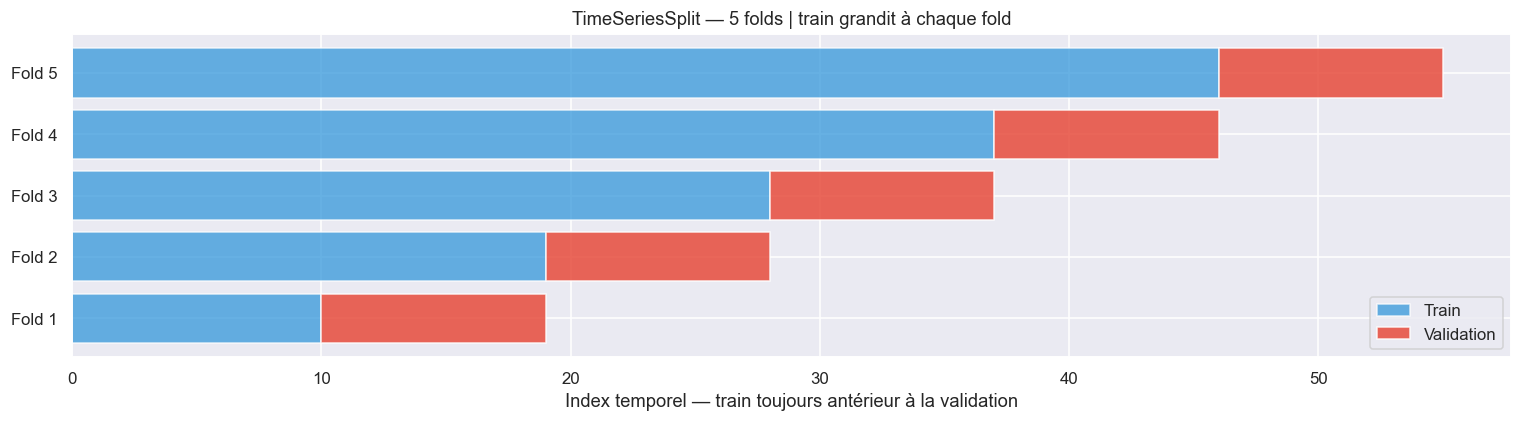

Fold      Train      Val  Séparation (index)
--------------------------------------------------
1            10        9  idx 9 → 10
2            19        9  idx 18 → 19
3            28        9  idx 27 → 28
4            37        9  idx 36 → 37
5            46        9  idx 45 → 46

✅ Aucun data leakage détecté dans les splits.


In [18]:
N_SPLITS = 5
splits = ds_builder.time_series_split(X, y, n_splits=N_SPLITS)

fig, ax = plt.subplots(figsize=(14, 4))
for fold_idx, (X_tr, X_val, _, _) in enumerate(splits):
    ax.barh(fold_idx, len(X_tr), left=X_tr.index[0], color='#3498db', alpha=0.75,
            label='Train' if fold_idx == 0 else '')
    ax.barh(fold_idx, len(X_val), left=X_val.index[0], color='#e74c3c', alpha=0.85,
            label='Validation' if fold_idx == 0 else '')

ax.set_yticks(range(N_SPLITS))
ax.set_yticklabels([f'Fold {i+1}' for i in range(N_SPLITS)])
ax.set_xlabel('Index temporel — train toujours antérieur à la validation')
ax.set_title(f'TimeSeriesSplit — {N_SPLITS} folds | train grandit à chaque fold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'{"Fold":<6} {"Train":>8} {"Val":>8}  Séparation (index)')
print('-' * 50)
for i, (X_tr, X_val, y_tr, y_val) in enumerate(splits):
    # Vérification anti-leakage : index max train < index min val (obligatoire)
    assert X_tr.index.max() < X_val.index.min(), f'Fold {i+1} : data leakage !'
    print(f'{i+1:<6} {len(X_tr):>8} {len(X_val):>8}  idx {X_tr.index[-1]} → {X_val.index[0]}')

print('\n✅ Aucun data leakage détecté dans les splits.')

2026-03-29 16:57:27,838 - crypto_bot - INFO - DatasetBuilder.train_test_split_temporal : train=44, test=11 (ratio=0.2).


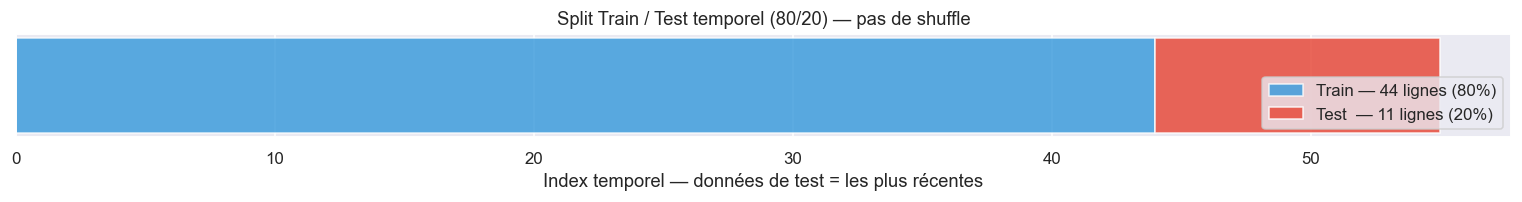

Train : 44 lignes  |  Test : 11 lignes
✅ Index max train (43) < index min test (44)


In [19]:
# Split train / test simple (80/20) pour l'évaluation finale
# Le test set = la portion la plus RÉCENTE — jamais de shuffle avant ce split.
X_train, X_test, y_train, y_test = ds_builder.train_test_split_temporal(X, y, test_ratio=0.2)

fig, ax = plt.subplots(figsize=(14, 2))
ax.barh(0, len(X_train), left=0, color='#3498db', alpha=0.8,
        label=f'Train — {len(X_train)} lignes ({len(X_train)/len(X)*100:.0f}%)')
ax.barh(0, len(X_test), left=len(X_train), color='#e74c3c', alpha=0.85,
        label=f'Test  — {len(X_test)} lignes ({len(X_test)/len(X)*100:.0f}%)')
ax.set_yticks([])
ax.set_xlabel('Index temporel — données de test = les plus récentes')
ax.set_title('Split Train / Test temporel (80/20) — pas de shuffle')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

assert X_train.index.max() < X_test.index.min()
print(f'Train : {len(X_train)} lignes  |  Test : {len(X_test)} lignes')
print(f'✅ Index max train ({X_train.index.max()}) < index min test ({X_test.index.min()})')

## 7. Corrélation features → target

Mesure de la **pertinence individuelle** de chaque feature (corrélation linéaire de Pearson).

> Attention : mesure linéaire uniquement. Des features non-linéairement prédictives
> (ex. RSI en zone extrême > 70 ou < 30) peuvent scorer faible ici mais rester très utiles
> pour les modèles d'arbres (LightGBM, XGBoost).

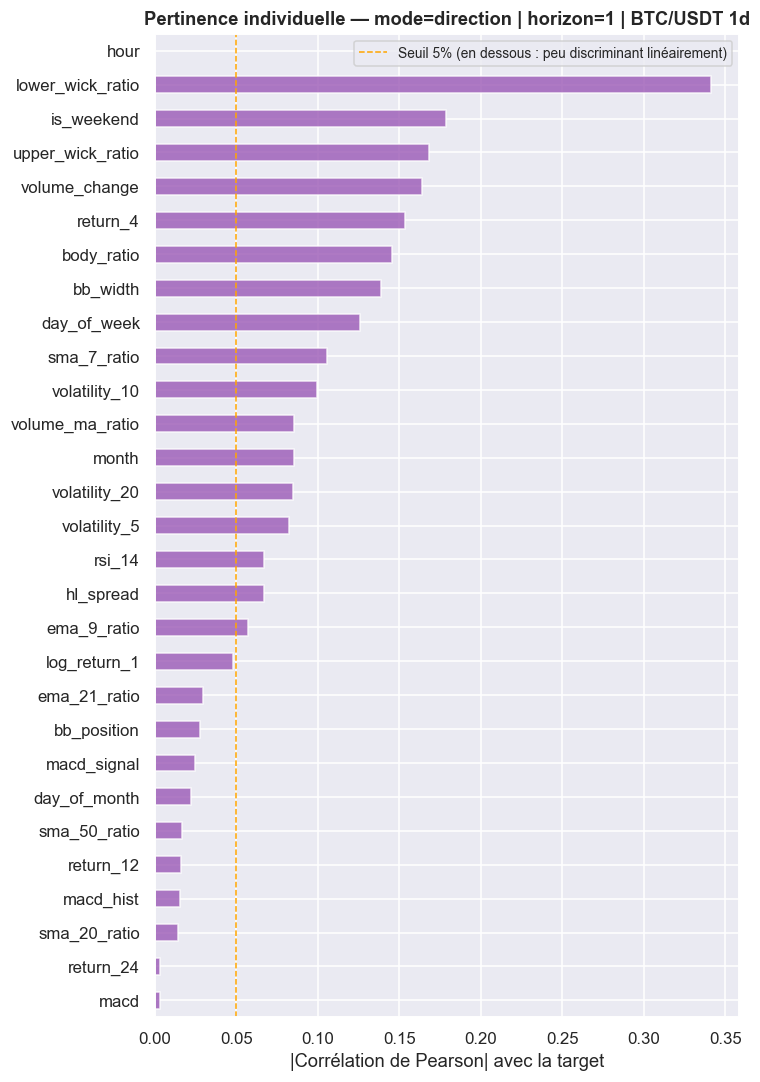

Top 10 features les plus corrélées à la target :
  lower_wick_ratio           0.3414  ████████████████████████████████████████████████████████████████████
  is_weekend                 0.1789  ███████████████████████████████████
  upper_wick_ratio           0.1684  █████████████████████████████████
  volume_change              0.1638  ████████████████████████████████
  return_4                   0.1536  ██████████████████████████████
  body_ratio                 0.1458  █████████████████████████████
  bb_width                   0.1388  ███████████████████████████
  day_of_week                0.1262  █████████████████████████
  sma_7_ratio                0.1058  █████████████████████
  volatility_10              0.0994  ███████████████████


In [20]:
feature_target_corr = X.corrwith(y).abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 10))
feature_target_corr.plot(kind='barh', ax=ax, color='#9b59b6', alpha=0.8)
ax.axvline(0.05, color='orange', linestyle='--', linewidth=1,
           label='Seuil 5% (en dessous : peu discriminant linéairement)')
ax.set_xlabel('|Corrélation de Pearson| avec la target')
ax.set_title(f'Pertinence individuelle — mode={MODE} | horizon={HORIZON} | {SYMBOL} {TIMEFRAME}',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('Top 10 features les plus corrélées à la target :')
for feat, val in feature_target_corr.sort_values(ascending=False).head(10).items():
    print(f'  {feat:<25}  {val:.4f}  {"█" * int(val * 200)}')

## 8. Récapitulatif

Résumé complet du dataset prêt pour la **Phase 2 — Modèles baseline**.

In [21]:
print('=' * 58)
print('  RÉCAPITULATIF DU DATASET ML')
print('=' * 58)
print(f'  Symbol         : {SYMBOL}')
print(f'  Timeframe      : {TIMEFRAME}  |  Exchange : {EXCHANGE}')
print(f"  Période        : {raw['timestamp'].min().date()}  →  {raw['timestamp'].max().date()}")
print(f'  Bougies brutes : {len(raw)}')
print(f'  Bougies ML     : {len(X)}  ({len(raw)-len(X)} supprimées — NaN warm-up + horizon)')
print(f'  Features       : {X.shape[1]}')
print(f'  Target         : mode={MODE}, horizon={HORIZON} bougie(s)')
if MODE == 'direction':
    print(f'  Balance        : {(y==1).mean()*100:.1f}% hausse / {(y==0).mean()*100:.1f}% baisse')
print(f'  Train          : {len(X_train)} lignes')
print(f'  Test           : {len(X_test)} lignes')
print(f'  NaN dans X     : {X.isna().sum().sum()}')
print(f'  NaN dans y     : {y.isna().sum()}')
print('=' * 58)
print('  ✅ Dataset prêt pour la Phase 2 — Modèles baseline')
print('=' * 58)

  RÉCAPITULATIF DU DATASET ML
  Symbol         : BTC/USDT
  Timeframe      : 1d  |  Exchange : binance
  Période        : 2025-11-02  →  2026-02-13
  Bougies brutes : 104
  Bougies ML     : 55  (49 supprimées — NaN warm-up + horizon)
  Features       : 29
  Target         : mode=direction, horizon=1 bougie(s)
  Balance        : 45.5% hausse / 54.5% baisse
  Train          : 44 lignes
  Test           : 11 lignes
  NaN dans X     : 0
  NaN dans y     : 0
  ✅ Dataset prêt pour la Phase 2 — Modèles baseline
